In [66]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
from IPython.display import HTML
import json
matplotlib.use('module://matplotlib_inline.backend_inline')

In [67]:
df = pd.read_csv("dataset.csv")
df.head()

C:\Users\dahot\AppData\Local\Temp\ipykernel_3744\1084434047.py:1: DtypeWarning: Columns (0: season) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dataset.csv")


,match_id,date,season,event,venue,city,team1,team2,toss_winner,toss_decision,...,non_striker,runs_batter,runs_extras,runs_total,extras_wides,extras_noballs,extras_byes,extras_legbyes,wicket_kind,wicket_player_out
0,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
1,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
2,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,4,0,4,0,0,0,0,NaN,NaN
3,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
4,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,2,2,2,0,0,0,NaN,NaN


In [68]:
print(df.columns)
df.drop(columns=['event'], inplace=True)
print(df.columns)

Index(['match_id', 'date', 'season', 'event', 'venue', 'city', 'team1',
       'team2', 'toss_winner', 'toss_decision', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'innings', 'batting_team', 'over',
       'ball', 'batter', 'bowler', 'non_striker', 'runs_batter', 'runs_extras',
       'runs_total', 'extras_wides', 'extras_noballs', 'extras_byes',
       'extras_legbyes', 'wicket_kind', 'wicket_player_out'],
      dtype='str')
Index(['match_id', 'date', 'season', 'venue', 'city', 'team1', 'team2',
       'toss_winner', 'toss_decision', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'innings', 'batting_team', 'over',
       'ball', 'batter', 'bowler', 'non_striker', 'runs_batter', 'runs_extras',
       'runs_total', 'extras_wides', 'extras_noballs', 'extras_byes',
       'extras_legbyes', 'wicket_kind', 'wicket_player_out'],
      dtype='str')


In [69]:
#Adjusting datetime

df['date'] = pd.to_datetime(df['date'])


In [70]:
print(f"Total Number of matches = {df['match_id'].nunique()}")
print(f"Total Balls Data: {df.shape[0]}")
print(f"Total Data Points: {df.shape[0] * df.shape[1]}")

Total Number of matches = 1218
Total Balls Data: 289673
Total Data Points: 8400517


In [71]:
print("Null Values Ananlysis")
df.isnull().sum()

Null Values Ananlysis


match_id                  0
date                      0
season                    0
venue                     0
city                  12397
team1                     0
team2                     0
toss_winner               0
toss_decision             0
winner                    0
win_by_runs          156126
win_by_wickets       138527
player_of_match         828
innings                   0
batting_team              0
over                      0
ball                      0
batter                    0
bowler                    0
non_striker               0
runs_batter               0
runs_extras               0
runs_total                0
extras_wides              0
extras_noballs            0
extras_byes               0
extras_legbyes            0
wicket_kind          275267
wicket_player_out    275267
dtype: int64

In [72]:
df.head()

,match_id,date,season,venue,city,team1,team2,toss_winner,toss_decision,winner,...,non_striker,runs_batter,runs_extras,runs_total,extras_wides,extras_noballs,extras_byes,extras_legbyes,wicket_kind,wicket_player_out
0,1082591,2017-04-05,2017,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
1,1082591,2017-04-05,2017,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
2,1082591,2017-04-05,2017,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,...,S Dhawan,4,0,4,0,0,0,0,NaN,NaN
3,1082591,2017-04-05,2017,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
4,1082591,2017-04-05,2017,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,...,S Dhawan,0,2,2,2,0,0,0,NaN,NaN


In [73]:
#Fixing inconsistent categorical labels 
print("Old Naming Conventions - ")
print(df['team1'].value_counts())
team_name_corrections = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiants': 'Rising Pune Supergiant'
}
team_columns = ['team1', 'team2', 'toss_winner', 'winner']
for col in team_columns:
    df[col] = df[col].replace(team_name_corrections)
print("\nUpdated naming Conventions")   
print(df['team1'].value_counts())

print(f"Total Teams: {len(df['team1'].unique())}")

#Venue Corrections
venue_corrections = {

    # Eden Gardens
    'Eden Gardens, Kolkata': 'Eden Gardens',

    # Wankhede
    'Wankhede Stadium, Mumbai': 'Wankhede Stadium',

    # Chinnaswamy
    'M Chinnaswamy Stadium, Bengaluru': 'M Chinnaswamy Stadium',
    'M.Chinnaswamy Stadium': 'M Chinnaswamy Stadium',

    # Chepauk
    'MA Chidambaram Stadium, Chepauk, Chennai': 'MA Chidambaram Stadium',
    'MA Chidambaram Stadium, Chepauk': 'MA Chidambaram Stadium',

    # Uppal
    'Rajiv Gandhi International Stadium, Uppal': 'Rajiv Gandhi International Stadium',
    'Rajiv Gandhi International Stadium, Uppal, Hyderabad': 'Rajiv Gandhi International Stadium',

    # Arun Jaitley / Kotla
    'Feroz Shah Kotla': 'Arun Jaitley Stadium',
    'Arun Jaitley Stadium, Delhi': 'Arun Jaitley Stadium',

    # Mohali
    'Punjab Cricket Association Stadium, Mohali': 
        'Punjab Cricket Association IS Bindra Stadium',

    'Punjab Cricket Association IS Bindra Stadium, Mohali': 
        'Punjab Cricket Association IS Bindra Stadium',

    'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh': 
        'Punjab Cricket Association IS Bindra Stadium',

    # Pune
    'Maharashtra Cricket Association Stadium, Pune': 
        'Maharashtra Cricket Association Stadium',

    # DY Patil
    'Dr DY Patil Sports Academy, Mumbai': 
        'Dr DY Patil Sports Academy',

    # Vizag
    'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam':
        'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',

    # Dharamsala
    'Himachal Pradesh Cricket Association Stadium, Dharamsala':
        'Himachal Pradesh Cricket Association Stadium',

    # Mullanpur
    'Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh':
        'Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur',

    # Abu Dhabi
    'Zayed Cricket Stadium, Abu Dhabi':
        'Sheikh Zayed Stadium'
}

df['venue'] = df['venue'].replace(venue_corrections)
print("Also change the category label inconsistencies for the venue column")

Old Naming Conventions - 
team1
Chennai Super Kings            33958
Mumbai Indians                 32963
Royal Challengers Bangalore    31649
Kolkata Knight Riders          30973
Rajasthan Royals               26522
Sunrisers Hyderabad            24558
Kings XI Punjab                21848
Delhi Daredevils               19753
Delhi Capitals                 12072
Punjab Kings                   10476
Deccan Chargers                 9448
Lucknow Super Giants            8878
Gujarat Titans                  7189
Pune Warriors                   5483
Royal Challengers Bengaluru     5262
Gujarat Lions                   3784
Rising Pune Supergiants         1677
Rising Pune Supergiant          1617
Kochi Tuskers Kerala            1563
Name: count, dtype: int64

Updated naming Conventions
team1
Royal Challengers Bengaluru    36911
Chennai Super Kings            33958
Mumbai Indians                 32963
Punjab Kings                   32324
Delhi Capitals                 31825
Kolkata Knight Rider

In [74]:
print(df.value_counts('season'))
# ============================================================
# CLEAN SEASON COLUMN
# ============================================================

season_corrections = {
    '2007/08': '2008',
    '2009/10': '2010',
    '2020/21': '2021'
}

# Convert everything to string first
df['season'] = df['season'].astype(str)

# Replace inconsistent labels
df['season'] = df['season'].replace(season_corrections)

# Convert to integer
df['season'] = df['season'].astype(int)

print(df.value_counts('season'))

season
2013       18177
2022       17912
2023       17863
2012       17767
2024       17103
2020/21    14559
2009/10    14498
2014       14300
2018       14286
2016       14096
2017       13862
2015       13652
2009       13606
2007/08    13489
2011       13408
2026       11468
2025       10535
2019        9692
2021        8517
2025        6750
2021        5908
2019        4620
2011        3605
Name: count, dtype: int64
season
2021    28984
2013    18177
2022    17912
2023    17863
2012    17767
2025    17285
2024    17103
2011    17013
2010    14498
2019    14312
2014    14300
2018    14286
2016    14096
2017    13862
2015    13652
2009    13606
2008    13489
2026    11468
Name: count, dtype: int64


In [75]:
matches_df = df.groupby('match_id').agg(
    date = ('date', 'first'),
    season         = ('season',         'first'),
    team1          = ('team1',          'first'),
    team2          = ('team2',          'first'),
    toss_winner    = ('toss_winner',    'first'),
    toss_decision  = ('toss_decision',  'first'),
    winner         = ('winner',         'first'),
    venue          = ('venue',          'first'),
    city           = ('city',           'first'),
    player_of_match= ('player_of_match','first'),
    win_by_runs    = ('win_by_runs',    'first'),
    win_by_wickets = ('win_by_wickets', 'first'),
).reset_index()

# Add derived column after
matches_df['toss_won_match'] = matches_df['toss_winner'] == matches_df['winner']

print(f"Matches: {len(matches_df)}\nTotal Datapoints: {matches_df.shape[0] * matches_df.shape[1]}\n")
matches_df.info()

Matches: 1218
Total Datapoints: 17052

<class 'pandas.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   match_id         1218 non-null   int64         
 1   date             1218 non-null   datetime64[us]
 2   season           1218 non-null   int64         
 3   team1            1218 non-null   str           
 4   team2            1218 non-null   str           
 5   toss_winner      1218 non-null   str           
 6   toss_decision    1218 non-null   str           
 7   winner           1218 non-null   str           
 8   venue            1218 non-null   str           
 9   city             1167 non-null   str           
 10  player_of_match  1209 non-null   str           
 11  win_by_runs      547 non-null    float64       
 12  win_by_wickets   646 non-null    float64       
 13  toss_won_match   1218 non-null   bool          
dtypes: bool(1), 

In [76]:
matches_df.head()

,match_id,date,season,team1,team2,toss_winner,toss_decision,winner,venue,city,player_of_match,win_by_runs,win_by_wickets,toss_won_match
0,335982,2008-04-18,2008,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders,M Chinnaswamy Stadium,Bangalore,BB McCullum,140.0,NaN,False
1,335983,2008-04-19,2008,Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,Punjab Cricket Association IS Bindra Stadium,Chandigarh,MEK Hussey,33.0,NaN,True
2,335984,2008-04-19,2008,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,Arun Jaitley Stadium,Delhi,MF Maharoof,NaN,9.0,False
3,335985,2008-04-20,2008,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Royal Challengers Bengaluru,Wankhede Stadium,Mumbai,MV Boucher,NaN,5.0,False
4,335986,2008-04-20,2008,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,Eden Gardens,Kolkata,DJ Hussey,NaN,5.0,False


In [77]:
#Toss and winning analysis
team_toss_df = matches_df.groupby('toss_winner')['toss_won_match'].agg(
    total_tosses='count',
    toss_and_match_wins='sum'
).reset_index()

team_toss_df['toss_and_match_losses'] = (
    team_toss_df['total_tosses']
    - team_toss_df['toss_and_match_wins']
)
team_toss_df['toss_win_rate'] = (
    team_toss_df['toss_and_match_wins']
    / team_toss_df['total_tosses']
    * 100
).round(1)
team_toss_df

,toss_winner,total_tosses,toss_and_match_wins,toss_and_match_losses,toss_win_rate
0,Chennai Super Kings,130,78,52,60.0
1,Deccan Chargers,43,19,24,44.2
2,Delhi Capitals,146,67,79,45.9
3,Gujarat Lions,15,10,5,66.7
4,Gujarat Titans,34,23,11,67.6
5,Kochi Tuskers Kerala,8,4,4,50.0
6,Kolkata Knight Riders,132,71,61,53.8
7,Lucknow Super Giants,29,15,14,51.7
8,Mumbai Indians,158,84,74,53.2
9,Pune Warriors,20,3,17,15.0


C:\Users\dahot\AppData\Local\Temp\ipykernel_3744\820707791.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


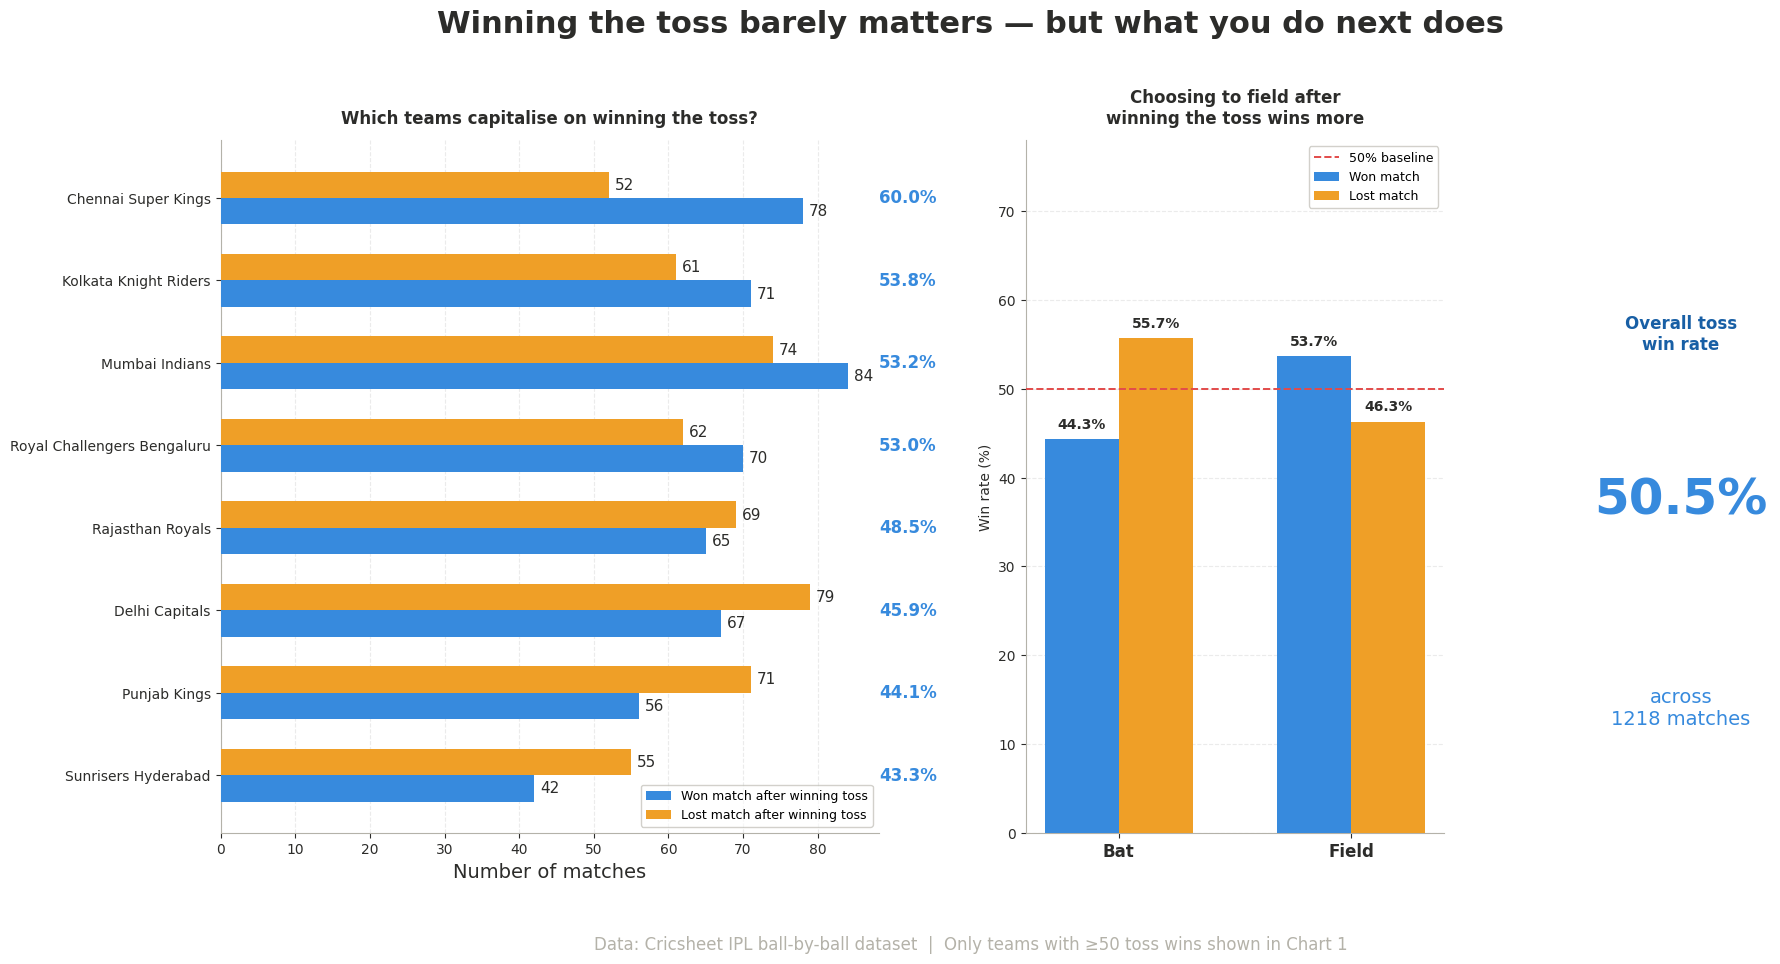

In [78]:


# ── Palette ──────────────────────────────────────────────────
BLUE   = '#378ADD'
YELLOW = '#EF9F27'
RED    = '#E24B4A'
GRAY   = '#B4B2A9'
DARK   = '#2C2C2A'

# ── Data Prep ────────────────────────────────────────────────

# Chart 1 — Team-wise toss impact
team_toss_df = matches_df.groupby('toss_winner')['toss_won_match'].agg(
    total_tosses        = 'count',
    toss_and_match_wins = 'sum'
).reset_index()

team_toss_df['toss_and_match_losses'] = (
    team_toss_df['total_tosses'] - team_toss_df['toss_and_match_wins']
)
team_toss_df['win_rate'] = (
    team_toss_df['toss_and_match_wins'] / team_toss_df['total_tosses'] * 100
).round(1)

# Keep only teams with enough matches
team_toss_df = team_toss_df[team_toss_df['total_tosses'] >= 50]
team_toss_df = team_toss_df.sort_values('win_rate', ascending=True)

# Chart 2 — Toss decision impact (as win rates)
decision_df = matches_df.groupby('toss_decision')['toss_won_match'].agg(
    total = 'count',
    wins  = 'sum'
).reset_index()
decision_df['win_rate']  = (decision_df['wins'] / decision_df['total'] * 100).round(1)
decision_df['loss_rate'] = (100 - decision_df['win_rate']).round(1)

# Chart 3 — Overall summary (single stat)
overall_rate = round(matches_df['toss_won_match'].mean() * 100, 1)

# ── Figure Setup ─────────────────────────────────────────────
fig = plt.figure(figsize=(20, 9), facecolor='white')
fig.patch.set_facecolor('white')

# Grid: left chart takes 55%, right takes 35%, stat card 10%
gs = fig.add_gridspec(1, 3, width_ratios=[5.5, 3.5, 1.5], wspace=0.35)
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])

# ── Chart 1 — Team-wise horizontal bars ──────────────────────
y      = np.arange(len(team_toss_df))
height = 0.32

b1 = ax0.barh(y - height/2, team_toss_df['toss_and_match_wins'],
              height=height, color=BLUE,   label='Won match after winning toss',  zorder=3)
b2 = ax0.barh(y + height/2, team_toss_df['toss_and_match_losses'],
              height=height, color=YELLOW, label='Lost match after winning toss', zorder=3)

ax0.set_yticks(y)
ax0.set_yticklabels(team_toss_df['toss_winner'], fontsize=10, color=DARK)
ax0.set_xlabel('Number of matches', fontsize=14, color=DARK)
ax0.set_title('Which teams capitalise on winning the toss?',
              fontsize=12, fontweight='bold', color=DARK, pad=12)

# Win rate annotation on each team row
for i, (_, row) in enumerate(team_toss_df.iterrows()):
    ax0.text(row['toss_and_match_wins'] + 0.8, i - height/2,
             f"{int(row['toss_and_match_wins'])}", va='center', fontsize=11, color=DARK)
    ax0.text(row['toss_and_match_losses'] + 0.8, i + height/2,
             f"{int(row['toss_and_match_losses'])}", va='center', fontsize=11, color=DARK)
    ax0.text(ax0.get_xlim()[1] if ax0.get_xlim()[1] > 1 else 80,
             i, f"{row['win_rate']}%", va='center', ha='left',
             fontsize=12, color=BLUE, fontweight='bold')

ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_color(GRAY)
ax0.spines['bottom'].set_color(GRAY)
ax0.tick_params(colors=DARK)
ax0.grid(axis='x', linestyle='--', alpha=0.25, zorder=0)
ax0.legend(fontsize=9, loc='lower right',
           framealpha=0.6, edgecolor=GRAY)

# ── Chart 2 — Bat vs Field decision ──────────────────────────
x     = np.arange(len(decision_df))
width = 0.32

b3 = ax1.bar(x - width/2, decision_df['win_rate'],  width,
             color=BLUE,   label='Won match',  zorder=3)
b4 = ax1.bar(x + width/2, decision_df['loss_rate'], width,
             color=YELLOW, label='Lost match', zorder=3)

ax1.axhline(50, color=RED, linestyle='--', linewidth=1.4,
            label='50% baseline', zorder=4)

ax1.set_xticks(x)
ax1.set_xticklabels(
    decision_df['toss_decision'].str.capitalize(),
    fontsize=12, fontweight='bold', color=DARK
)
ax1.set_ylabel('Win rate (%)', fontsize=10, color=DARK)
ax1.set_ylim(0, 78)
ax1.set_title('Choosing to field after\nwinning the toss wins more',
              fontsize=12, fontweight='bold', color=DARK, pad=12)

for bar in [*b3, *b4]:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1.2,
             f"{bar.get_height():.1f}%",
             ha='center', fontsize=10, fontweight='bold', color=DARK)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color(GRAY)
ax1.spines['bottom'].set_color(GRAY)
ax1.tick_params(colors=DARK)
ax1.grid(axis='y', linestyle='--', alpha=0.25, zorder=0)
ax1.legend(fontsize=9, framealpha=0.6, edgecolor=GRAY)

# ── Stat Card — Overall toss win rate ────────────────────────
ax2.set_facecolor('#EBF4FC')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')

ax2.text(0.5, 0.72, 'Overall toss\nwin rate',
         ha='center', va='center', fontsize=12,
         color='#185FA5', fontweight='bold')
ax2.text(0.5, 0.48, f'{overall_rate}%',
         ha='center', va='center', fontsize=36,
         color=BLUE, fontweight='bold')
ax2.text(0.5, 0.18, f'across\n{len(matches_df)} matches',
         ha='center', va='center', fontsize=14, color='#378ADD')


for spine in ax2.spines.values():
    spine.set_visible(False)

# ── Supertitle & Footer ──────────────────────────────────────
fig.suptitle('Winning the toss barely matters — but what you do next does',
             fontsize=22, fontweight='bold', color=DARK, y=1.025)

fig.text(0.5, -0.02,
         'Data: Cricsheet IPL ball-by-ball dataset  |  Only teams with ≥50 toss wins shown in Chart 1',
         ha='center', fontsize=12, color=GRAY)

plt.tight_layout()
plt.show()

C:\Users\dahot\AppData\Local\Temp\ipykernel_3744\2811964470.py:231: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


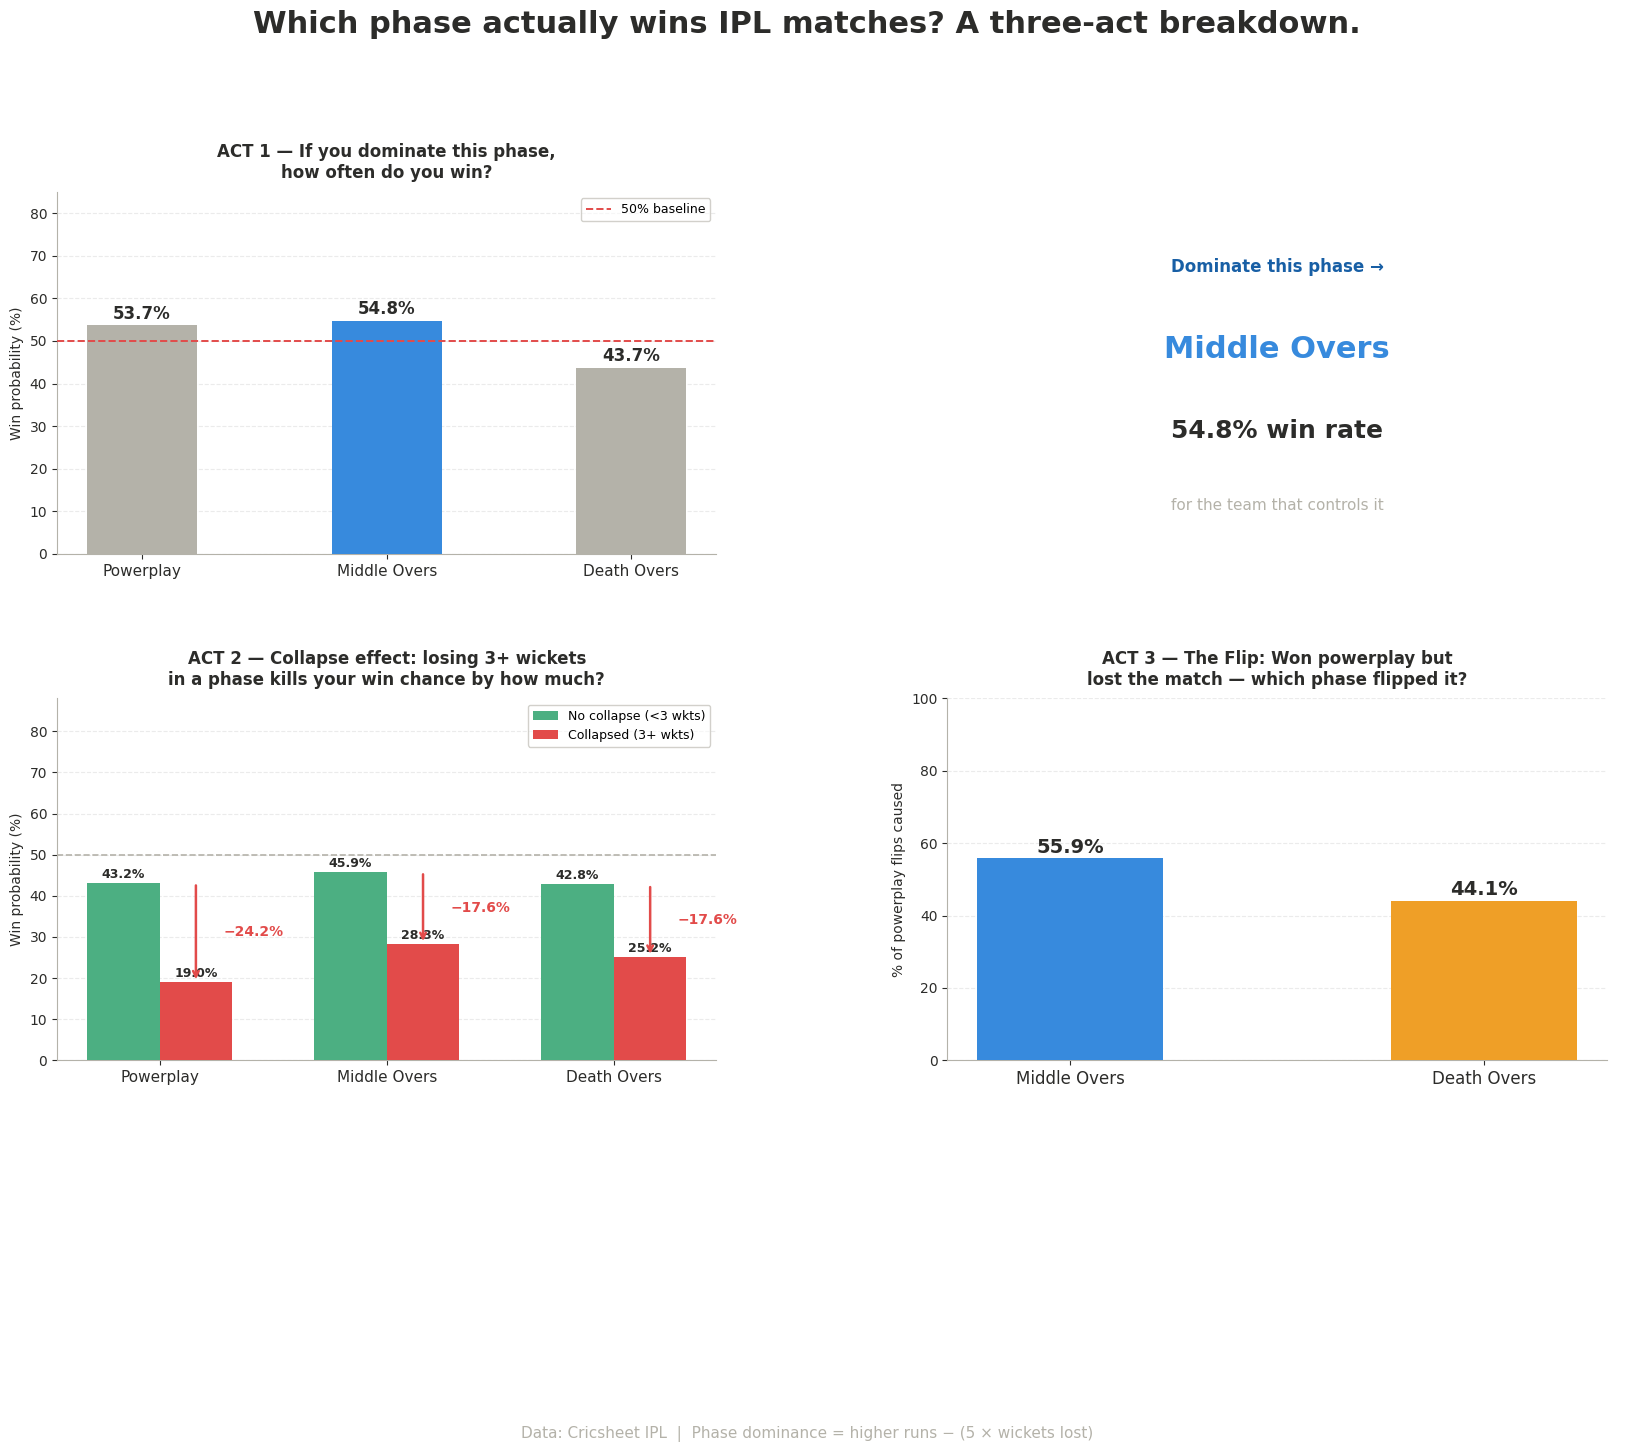

In [79]:

# ── Palette ───────────────────────────────────────────────────
BLUE   = '#378ADD'
YELLOW = '#EF9F27'
RED    = '#E24B4A'
GRAY   = '#B4B2A9'
DARK   = '#2C2C2A'
GREEN  = '#4CAF82'

# ── Phase tag ────────────────────────────────────────────────
def classify_phase(over):
    o = int(over)
    if o <= 6:    return 'Powerplay'
    elif o <= 15: return 'Middle Overs'
    else:         return 'Death Overs'

df['phase']            = df['over'].astype(int).apply(classify_phase)
df['is_wicket']        = df['wicket_kind'].notna().astype(int)
df['batting_team_won'] = (df['batting_team'] == df['winner']).astype(int)

PHASE_ORDER = ['Powerplay', 'Middle Overs', 'Death Overs']

# ════════════════════════════════════════════════════════════
# ACT 1 — Phase Dominance → Win Probability
# ════════════════════════════════════════════════════════════
phase_stats = df.groupby(
    ['match_id', 'innings', 'batting_team', 'batting_team_won', 'phase']
).agg(runs=('runs_total','sum'), wickets=('is_wicket','sum')).reset_index()

phase_stats = phase_stats[phase_stats['innings'].isin([1, 2])].copy()
phase_stats['dom_score'] = phase_stats['runs'] - 5 * phase_stats['wickets']

phase_stats['rank'] = phase_stats.groupby(
    ['match_id', 'phase']
)['dom_score'].rank(ascending=False, method='first')

phase_dom = phase_stats[phase_stats['rank'] == 1].copy()

# Remove ties
tie_counts = phase_stats.groupby(['match_id', 'phase'])['rank'].apply(
    lambda x: (x == 1).sum()
).reset_index()
tie_counts.columns = ['match_id', 'phase', 'n_rank1']
ties = tie_counts[tie_counts['n_rank1'] > 1][['match_id', 'phase']]

phase_dom = phase_dom.merge(ties, on=['match_id', 'phase'], how='left', indicator=True)
phase_dom = phase_dom[phase_dom['_merge'] == 'left_only'].drop(columns='_merge')

act1 = phase_dom.groupby('phase')['batting_team_won'].agg(
    win_pct=lambda x: round(x.mean() * 100, 1)
).reindex(PHASE_ORDER).reset_index()
act1.columns = ['phase', 'win_pct']

# ════════════════════════════════════════════════════════════
# ACT 2 — Collapse Effect (3+ wickets in a phase)
# ════════════════════════════════════════════════════════════
collapse_df    = phase_stats[phase_stats['wickets'] >= 3].copy()
no_collapse_df = phase_stats[phase_stats['wickets'] <  3].copy()

collapse_win = collapse_df.groupby('phase')['batting_team_won'].agg(
    collapse_win_pct=lambda x: round(x.mean() * 100, 1)
).reindex(PHASE_ORDER).reset_index()

no_collapse_win = no_collapse_df.groupby('phase')['batting_team_won'].agg(
    no_collapse_win_pct=lambda x: round(x.mean() * 100, 1)
).reindex(PHASE_ORDER).reset_index()

act2 = collapse_win.merge(no_collapse_win, on='phase')
act2['penalty'] = (act2['no_collapse_win_pct'] - act2['collapse_win_pct']).round(1)

# ════════════════════════════════════════════════════════════
# ACT 3 — The Flip
# ════════════════════════════════════════════════════════════
pp_dom = phase_dom[phase_dom['phase'] == 'Powerplay'].copy()
pp_dom_lost_matches = pp_dom[pp_dom['batting_team_won'] == 0]['match_id'].unique()

flipped = phase_dom[
    (phase_dom['match_id'].isin(pp_dom_lost_matches)) &
    (phase_dom['phase'] != 'Powerplay') &
    (phase_dom['batting_team_won'] == 1)
]

act3 = flipped.groupby('phase').size().reindex(
    ['Middle Overs', 'Death Overs']
).fillna(0).reset_index()
act3.columns = ['phase', 'flip_count']
act3['flip_pct'] = (act3['flip_count'] / act3['flip_count'].sum() * 100).round(1)

# ════════════════════════════════════════════════════════════
# FIGURE
# ════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 14), facecolor='white')
fig.patch.set_facecolor('white')

gs = fig.add_gridspec(3, 2,
                      height_ratios=[1, 1, 0.18],
                      hspace=0.55, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
ax_verdict = fig.add_subplot(gs[2, :])

x     = np.arange(len(PHASE_ORDER))
width = 0.45

# ── ACT 1 LEFT: Phase dominance win % ────────────────────────
colors1 = [BLUE if v == act1['win_pct'].max() else GRAY for v in act1['win_pct']]
bars1   = ax1.bar(x, act1['win_pct'], width, color=colors1, zorder=3)
ax1.axhline(50, color=RED, linestyle='--', linewidth=1.4, zorder=4, label='50% baseline')
ax1.set_xticks(x)
ax1.set_xticklabels(PHASE_ORDER, fontsize=11, color=DARK)
ax1.set_ylabel('Win probability (%)', fontsize=10, color=DARK)
ax1.set_ylim(0, 85)
ax1.set_title('ACT 1 — If you dominate this phase,\nhow often do you win?',
              fontsize=12, fontweight='bold', color=DARK, pad=10)
for bar, val in zip(bars1, act1['win_pct']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1.5,
             f"{val}%", ha='center', fontsize=12,
             fontweight='bold', color=DARK)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color(GRAY)
ax1.spines['bottom'].set_color(GRAY)
ax1.tick_params(colors=DARK)
ax1.grid(axis='y', linestyle='--', alpha=0.25, zorder=0)
ax1.legend(fontsize=9, framealpha=0.6, edgecolor=GRAY)

# ── ACT 1 RIGHT: Insight card ─────────────────────────────────
best_phase = act1.loc[act1['win_pct'].idxmax(), 'phase']
best_val   = act1['win_pct'].max()
ax2.set_facecolor('#EBF4FC')
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1); ax2.axis('off')
ax2.text(0.5, 0.78, 'Dominate this phase →', ha='center',
         fontsize=12, color='#185FA5', fontweight='bold')
ax2.text(0.5, 0.54, best_phase, ha='center',
         fontsize=22, color=BLUE, fontweight='bold')
ax2.text(0.5, 0.32, f'{best_val}% win rate', ha='center',
         fontsize=18, color=DARK, fontweight='bold')
ax2.text(0.5, 0.12, 'for the team that controls it', ha='center',
         fontsize=11, color=GRAY)

# ── ACT 2 LEFT: Collapse penalty ─────────────────────────────
bar_w = 0.32
b_no  = ax3.bar(x - bar_w/2, act2['no_collapse_win_pct'], bar_w,
                color=GREEN, label='No collapse (<3 wkts)', zorder=3)
b_col = ax3.bar(x + bar_w/2, act2['collapse_win_pct'],    bar_w,
                color=RED,   label='Collapsed (3+ wkts)',  zorder=3)

ax3.axhline(50, color=GRAY, linestyle='--', linewidth=1.2, zorder=4)
ax3.set_xticks(x)
ax3.set_xticklabels(PHASE_ORDER, fontsize=11, color=DARK)
ax3.set_ylabel('Win probability (%)', fontsize=10, color=DARK)
ax3.set_ylim(0, 88)
ax3.set_title('ACT 2 — Collapse effect: losing 3+ wickets\nin a phase kills your win chance by how much?',
              fontsize=12, fontweight='bold', color=DARK, pad=10)

for bar in [*b_no, *b_col]:
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1.2,
             f"{bar.get_height():.1f}%",
             ha='center', fontsize=9, fontweight='bold', color=DARK)

# Penalty arrows
for i, row in act2.iterrows():
    ax3.annotate('', xy=(i + bar_w/2, row['collapse_win_pct']),
                 xytext=(i + bar_w/2, row['no_collapse_win_pct']),
                 arrowprops=dict(arrowstyle='->', color=RED, lw=1.8))
    ax3.text(i + bar_w/2 + 0.12,
             (row['collapse_win_pct'] + row['no_collapse_win_pct'])/2,
             f"−{row['penalty']}%", fontsize=10, color=RED,
             fontweight='bold', va='center')

ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_color(GRAY)
ax3.spines['bottom'].set_color(GRAY)
ax3.tick_params(colors=DARK)
ax3.grid(axis='y', linestyle='--', alpha=0.25, zorder=0)
ax3.legend(fontsize=9, framealpha=0.6, edgecolor=GRAY)

# ── ACT 3: Flip analysis ──────────────────────────────────────
flip_colors = [BLUE if v == act3['flip_pct'].max() else YELLOW for v in act3['flip_pct']]
x3   = np.arange(len(act3))
bars3 = ax4.bar(x3, act3['flip_pct'], 0.45, color=flip_colors, zorder=3)

ax4.set_xticks(x3)
ax4.set_xticklabels(act3['phase'], fontsize=12, color=DARK)
ax4.set_ylabel('% of powerplay flips caused', fontsize=10, color=DARK)
ax4.set_ylim(0, 100)
ax4.set_title('ACT 3 — The Flip: Won powerplay but\nlost the match — which phase flipped it?',
              fontsize=12, fontweight='bold', color=DARK, pad=10)

for bar, val in zip(bars3, act3['flip_pct']):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1.5,
             f"{val}%", ha='center', fontsize=14,
             fontweight='bold', color=DARK)

ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.spines['left'].set_color(GRAY)
ax4.spines['bottom'].set_color(GRAY)
ax4.tick_params(colors=DARK)
ax4.grid(axis='y', linestyle='--', alpha=0.25, zorder=0)

# ── VERDICT BANNER ────────────────────────────────────────────
worst_collapse = act2.loc[act2['penalty'].idxmax(), 'phase']
flip_phase     = act3.loc[act3['flip_pct'].idxmax(), 'phase']

ax_verdict.set_facecolor(DARK)
ax_verdict.set_xlim(0, 1); ax_verdict.set_ylim(0, 1); ax_verdict.axis('off')
verdict_text = (
    f"VERDICT  ·  Dominating {best_phase} gives the highest win rate ({best_val}%)  "
    f"·  Collapsing in {worst_collapse} hurts the most  "
    f"·  {flip_phase} is where powerplay leads get overturned"
)
ax_verdict.text(0.5, 0.5, verdict_text,
                ha='center', va='center', fontsize=12,
                color='white', fontweight='bold')

# ── Supertitle & Footer ───────────────────────────────────────
fig.suptitle('Which phase actually wins IPL matches? A three-act breakdown.',
             fontsize=22, fontweight='bold', color=DARK, y=1.01)

fig.text(0.5, -0.01,
         'Data: Cricsheet IPL  |  Phase dominance = higher runs − (5 × wickets lost)',
         ha='center', fontsize=11, color=GRAY)

plt.tight_layout()
plt.savefig('q2_phase_story.png', dpi=150, bbox_inches='tight')
plt.show()

In [80]:
# ============================================================
# Q2 — PHASE ANALYSIS  |  IPL Crunch '26
# ============================================================

# ── Phase Classification ──────────────────────────────────────
df['phase'] = pd.cut(
    df['over'],
    bins=[-1, 5, 15, 19],
    labels=['Powerplay', 'Middle Overs', 'Death Overs']
)

# ── Flag whether batting team won ────────────────────────────
df['batting_team_won'] = df['batting_team'] == df['winner']
df['result_label']     = df['batting_team_won'].map({True: 'Winners', False: 'Losers'})

# ── Aggregate per match + phase + result ─────────────────────
phase_match = df.groupby(
    ['match_id', 'phase', 'result_label'], observed=True
).agg(
    runs     = ('runs_total',          'sum'),
    wickets  = ('wicket_player_out',   'count'),
    balls    = ('runs_total',          'count')
).reset_index()

phase_match['run_rate'] = (phase_match['runs'] / phase_match['balls'] * 6).round(2)

# ── Average across all matches ────────────────────────────────
phase_avg = phase_match.groupby(
    ['phase', 'result_label'], observed=True
).agg(
    avg_runs     = ('runs',     'mean'),
    avg_wickets  = ('wickets',  'mean'),
    avg_run_rate = ('run_rate', 'mean')
).reset_index().round(2)

print(phase_avg)

          phase result_label  avg_runs  avg_wickets  avg_run_rate
0     Powerplay       Losers     57.10         2.06          7.36
1     Powerplay      Winners     51.95         1.10          8.33
2  Middle Overs       Losers     93.72         3.63          7.42
3  Middle Overs      Winners     83.81         2.18          8.32
4   Death Overs       Losers     43.69         2.70          8.86
5   Death Overs      Winners     38.99         1.54         10.96


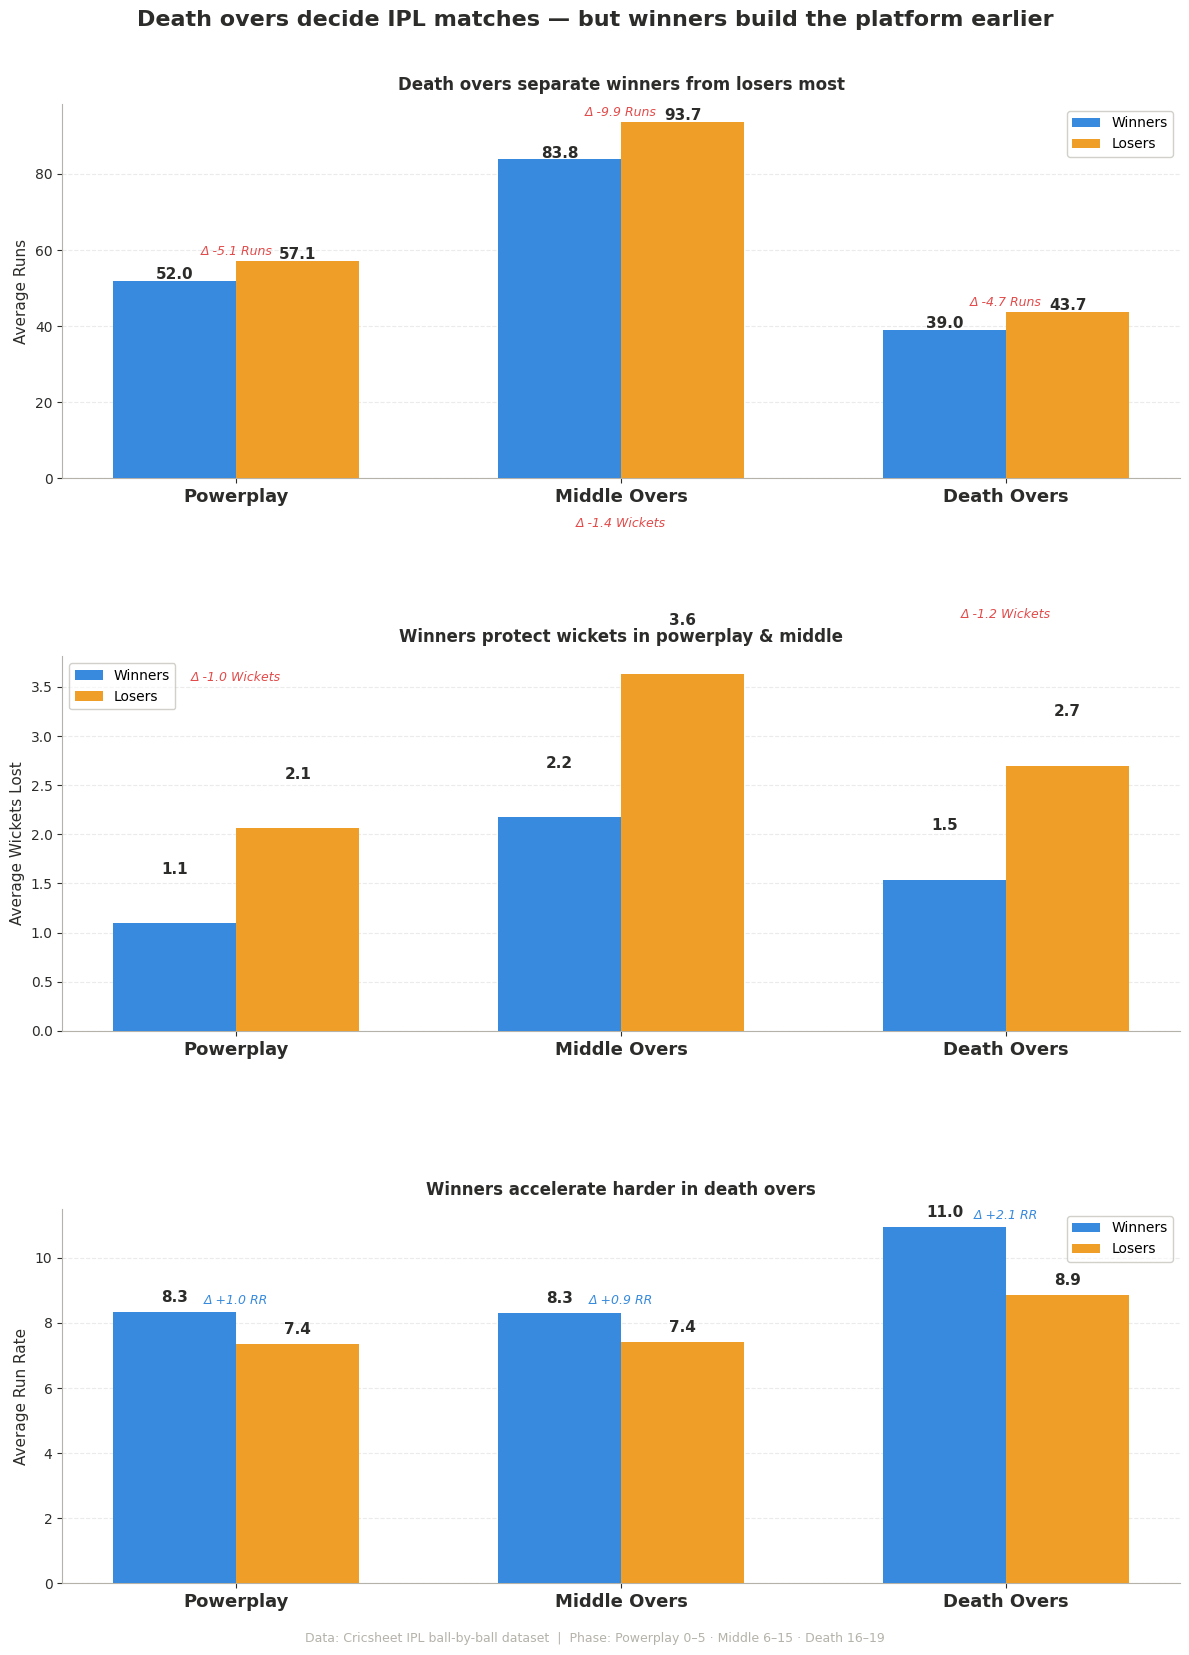

In [81]:
# ── Palette ──────────────────────────────────────────────────
BLUE   = '#378ADD'
YELLOW = '#EF9F27'
RED    = '#E24B4A'
GRAY   = '#B4B2A9'
DARK   = '#2C2C2A'

phases  = ['Powerplay', 'Middle Overs', 'Death Overs']
metrics = [
    ('avg_runs',     'Average Runs',          'Runs',    'Death overs separate winners from losers most'),
    ('avg_wickets',  'Average Wickets Lost',   'Wickets', 'Winners protect wickets in powerplay & middle'),
    ('avg_run_rate', 'Average Run Rate',       'RR',      'Winners accelerate harder in death overs'),
]

winners = phase_avg[phase_avg['result_label'] == 'Winners']
losers  = phase_avg[phase_avg['result_label'] == 'Losers']

x     = np.arange(len(phases))
width = 0.32

# ── Figure — 3 rows, 1 column ─────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 16), facecolor='white')
fig.patch.set_facecolor('white')

for i, (metric, ylabel, unit, subtitle) in enumerate(metrics):
    ax = axes[i]

    w_vals = [winners[winners['phase'] == p][metric].values[0] for p in phases]
    l_vals = [losers [losers ['phase'] == p][metric].values[0] for p in phases]

    b1 = ax.bar(x - width/2, w_vals, width, color=BLUE,   label='Winners', zorder=3)
    b2 = ax.bar(x + width/2, l_vals, width, color=YELLOW, label='Losers',  zorder=3)

    # Value labels
    for bar in [*b1, *b2]:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (0.3 if metric == 'avg_run_rate' else 0.5),
            f"{bar.get_height():.1f}",
            ha='center', fontsize=11, fontweight='bold', color=DARK
        )

    # Difference annotation above each phase
    for j, (w, l) in enumerate(zip(w_vals, l_vals)):
        diff = round(w - l, 1)
        sign = '+' if diff > 0 else ''
        color = BLUE if diff > 0 else RED
        ax.text(
            x[j], max(w, l) + (1.5 if metric != 'avg_run_rate' else 0.25),
            f"Δ {sign}{diff} {unit}",
            ha='center', fontsize=9, color=color, fontstyle='italic'
        )

    ax.set_xticks(x)
    ax.set_xticklabels(phases, fontsize=13, fontweight='bold', color=DARK)
    ax.set_ylabel(ylabel, fontsize=11, color=DARK)
    ax.set_title(subtitle, fontsize=12, fontweight='bold', color=DARK, pad=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(GRAY)
    ax.spines['bottom'].set_color(GRAY)
    ax.tick_params(colors=DARK)
    ax.grid(axis='y', linestyle='--', alpha=0.25, zorder=0)
    ax.legend(fontsize=10, framealpha=0.6, edgecolor=GRAY)

# ── Supertitle & Footer ───────────────────────────────────────
fig.suptitle('Death overs decide IPL matches — but winners build the platform earlier',
             fontsize=16, fontweight='bold', color=DARK, y=1.01)

fig.text(0.5, -0.01,
         'Data: Cricsheet IPL ball-by-ball dataset  |  Phase: Powerplay 0–5 · Middle 6–15 · Death 16–19',
         ha='center', fontsize=9, color=GRAY)

plt.tight_layout()
plt.show()

In [89]:
# ============================================================
# Q3 — INTERACTIVE PLAYER STATS TABLE  |  IPL Crunch '26
# ============================================================
from IPython.display import HTML
import json

# ── BATTER STATS ─────────────────────────────────────────────

balls_df = df[df['extras_wides'] == 0].copy()  # exclude wides from strike rate

batter_stats = balls_df.groupby(['batter', 'season']).agg(
    runs        = ('runs_batter',        'sum'),
    balls_faced = ('runs_batter',        'count'),
    fours       = ('runs_batter',        lambda x: (x == 4).sum()),
    sixes       = ('runs_batter',        lambda x: (x == 6).sum()),
).reset_index()

# Dismissals per batter per season
dismissals = df[df['wicket_player_out'].notna()].groupby(
    ['wicket_player_out', 'season']
).size().reset_index(name = 'dismissals')
dismissals.columns = ['batter', 'season', 'dismissals']

batter_stats = batter_stats.merge(dismissals, on=['batter', 'season'], how='left')
batter_stats['dismissals'] = batter_stats['dismissals'].fillna(1)  # avoid div/0

batter_stats['avg'] = (batter_stats['runs'] / batter_stats['dismissals']).round(1)
batter_stats['sr']  = (batter_stats['runs'] / batter_stats['balls_faced'] * 100).round(1)

# All-season totals
batter_all = balls_df.groupby('batter').agg(
    runs        = ('runs_batter',        'sum'),
    balls_faced = ('runs_batter',        'count'),
    fours       = ('runs_batter',        lambda x: (x == 4).sum()),
    sixes       = ('runs_batter',        lambda x: (x == 6).sum()),
).reset_index()

dismissals_all = df[df['wicket_player_out'].notna()].groupby(
    'wicket_player_out'
).size().reset_index()
dismissals_all.columns = ['batter', 'dismissals']

batter_all = batter_all.merge(dismissals_all, on='batter', how='left')
batter_all['dismissals'] = batter_all['dismissals'].fillna(1)
batter_all['avg']        = (batter_all['runs'] / batter_all['dismissals']).round(1)
batter_all['sr']         = (batter_all['runs'] / batter_all['balls_faced'] * 100).round(1)
batter_all['season']     = 'All'

batter_full = pd.concat([
    batter_stats[['batter','season','runs','balls_faced','avg','sr','fours','sixes']],
    batter_all[['batter','season','runs','balls_faced','avg','sr','fours','sixes']]
], ignore_index=True)

# ── BOWLER STATS ─────────────────────────────────────────────

bowler_stats = df.groupby(['bowler', 'season']).agg(
    runs_given  = ('runs_total',        'sum'),
    balls       = ('runs_total',        'count'),
    wickets     = ('wicket_player_out', 'count')
).reset_index()

bowler_stats['overs']    = (bowler_stats['balls'] / 6).round(1)
bowler_stats['economy']  = (bowler_stats['runs_given'] / bowler_stats['overs']).round(2)
bowler_stats['avg']      = (bowler_stats['runs_given'] / bowler_stats['wickets'].replace(0, np.nan)).round(1)
bowler_stats['bowl_sr']  = (bowler_stats['balls'] / bowler_stats['wickets'].replace(0, np.nan)).round(1)

bowler_all = df.groupby('bowler').agg(
    runs_given  = ('runs_total',        'sum'),
    balls       = ('runs_total',        'count'),
    wickets     = ('wicket_player_out', 'count')
).reset_index()

bowler_all['overs']   = (bowler_all['balls'] / 6).round(1)
bowler_all['economy'] = (bowler_all['runs_given'] / bowler_all['overs']).round(2)
bowler_all['avg']     = (bowler_all['runs_given'] / bowler_all['wickets'].replace(0, np.nan)).round(1)
bowler_all['bowl_sr'] = (bowler_all['balls'] / bowler_all['wickets'].replace(0, np.nan)).round(1)
bowler_all['season']  = 'All'

bowler_full = pd.concat([
    bowler_stats[['bowler','season','wickets','runs_given','overs','economy','avg','bowl_sr']],
    bowler_all[['bowler','season','wickets','runs_given','overs','economy','avg','bowl_sr']]
], ignore_index=True)

# ── Convert to JSON for JS ────────────────────────────────────
seasons_list = ['All'] + sorted(df['season'].dropna().unique().tolist())

batter_json = batter_full.to_json(orient='records')
bowler_json = bowler_full.to_json(orient='records')
seasons_json = json.dumps([str(s) for s in seasons_list])

# ── HTML Widget ───────────────────────────────────────────────
html = f"""
<style>
  #ipl-widget {{
    font-family: 'Segoe UI', sans-serif;
    background: #ffffff;
    border-radius: 12px;
    padding: 24px;
    max-width: 900px;
    box-shadow: 0 2px 16px rgba(0,0,0,0.08);
  }}
  #ipl-widget h2 {{
    font-size: 18px;
    color: #2C2C2A;
    margin: 0 0 4px;
  }}
  #ipl-widget p.sub {{
    font-size: 12px;
    color: #B4B2A9;
    margin: 0 0 18px;
  }}
  .controls {{
    display: flex;
    flex-wrap: wrap;
    gap: 10px;
    margin-bottom: 18px;
    align-items: center;
  }}
  .toggle-group {{
    display: flex;
    border-radius: 8px;
    overflow: hidden;
    border: 1.5px solid #378ADD;
  }}
  .toggle-btn {{
    padding: 7px 20px;
    font-size: 13px;
    font-weight: 600;
    cursor: pointer;
    background: white;
    color: #378ADD;
    border: none;
    transition: all 0.2s;
  }}
  .toggle-btn.active {{
    background: #378ADD;
    color: white;
  }}
  select {{
    padding: 7px 12px;
    border-radius: 8px;
    border: 1.5px solid #e0e0e0;
    font-size: 13px;
    color: #2C2C2A;
    background: white;
    cursor: pointer;
    outline: none;
  }}
  select:focus {{ border-color: #378ADD; }}
  label {{
    font-size: 12px;
    color: #888;
    margin-right: -6px;
  }}
  table {{
    width: 100%;
    border-collapse: collapse;
    font-size: 13px;
  }}
  thead tr {{
    background: #F4F8FD;
  }}
  th {{
    padding: 10px 12px;
    text-align: left;
    font-size: 11px;
    font-weight: 700;
    color: #378ADD;
    text-transform: uppercase;
    letter-spacing: 0.5px;
    cursor: pointer;
    user-select: none;
    white-space: nowrap;
  }}
  th:hover {{ background: #EBF4FC; }}
  th.sorted {{ color: #E24B4A; }}
  td {{
    padding: 10px 12px;
    border-bottom: 1px solid #f0f0f0;
    color: #2C2C2A;
    white-space: nowrap;
  }}
  tr:hover td {{ background: #FAFCFF; }}
  .rank-badge {{
    display: inline-block;
    width: 24px;
    height: 24px;
    border-radius: 50%;
    text-align: center;
    line-height: 24px;
    font-size: 11px;
    font-weight: 700;
  }}
  .rank-1 {{ background: #FFD700; color: #7A5800; }}
  .rank-2 {{ background: #C0C0C0; color: #444; }}
  .rank-3 {{ background: #CD7F32; color: #fff; }}
  .rank-other {{ background: #F0F0F0; color: #666; }}
  .player-name {{ font-weight: 600; color: #2C2C2A; }}
  .highlight {{ color: #378ADD; font-weight: 700; }}
  .bar-cell {{ display: flex; align-items: center; gap: 8px; }}
  .bar-bg {{
    height: 6px;
    background: #EEF4FB;
    border-radius: 3px;
    flex: 1;
    min-width: 60px;
  }}
  .bar-fill {{
    height: 100%;
    border-radius: 3px;
    background: #378ADD;
  }}
  .no-data {{
    text-align: center;
    padding: 40px;
    color: #B4B2A9;
    font-size: 14px;
  }}
  .stats-summary {{
    display: flex;
    gap: 16px;
    margin-bottom: 16px;
    flex-wrap: wrap;
  }}
  .stat-pill {{
    background: #F4F8FD;
    border-radius: 8px;
    padding: 8px 14px;
    font-size: 12px;
    color: #185FA5;
  }}
  .stat-pill span {{
    font-size: 16px;
    font-weight: 700;
    display: block;
    color: #378ADD;
  }}
</style>

<div id="ipl-widget">
  <h2>🏏 IPL Player Stats Explorer</h2>
  <p class="sub">Interactive leaderboard — sort by any metric, filter by season</p>

  <div class="controls">
    <div class="toggle-group">
      <button class="toggle-btn active" onclick="setMode('batter')">🏏 Batters</button>
      <button class="toggle-btn"        onclick="setMode('bowler')">🎳 Bowlers</button>
    </div>
    <div style="display:flex;align-items:center;gap:6px;">
      <label>Season</label>
      <select id="season-select" onchange="render()"></select>
    </div>
    <div style="display:flex;align-items:center;gap:6px;">
      <label>Sort by</label>
      <select id="sort-select" onchange="render()"></select>
    </div>
    <div style="display:flex;align-items:center;gap:6px;">
      <label>Show top</label>
      <select id="top-select" onchange="render()">
        <option value="5">5</option>
        <option value="10" selected>10</option>
        <option value="15">15</option>
        <option value="20">20</option>
      </select>
    </div>
  </div>

  <div class="stats-summary" id="summary-pills"></div>
  <div id="table-container"></div>
</div>

<script>
const BATTER_DATA  = {batter_json};
const BOWLER_DATA  = {bowler_json};
const SEASONS      = {seasons_json};

const BATTER_COLS = [
  {{ key: 'runs',        label: 'Runs',         fmt: v => v?.toLocaleString() ?? '-' }},
  {{ key: 'avg',         label: 'Average',      fmt: v => v ?? '-' }},
  {{ key: 'sr',          label: 'Strike Rate',  fmt: v => v ?? '-' }},
  {{ key: 'balls_faced', label: 'Balls',        fmt: v => v?.toLocaleString() ?? '-' }},
  {{ key: 'fours',       label: '4s',           fmt: v => v ?? '-' }},
  {{ key: 'sixes',       label: '6s',           fmt: v => v ?? '-' }},
];

const BOWLER_COLS = [
  {{ key: 'wickets',    label: 'Wickets',   fmt: v => v ?? '-' }},
  {{ key: 'economy',   label: 'Economy',   fmt: v => v ?? '-' }},
  {{ key: 'avg',       label: 'Average',   fmt: v => v ?? '-' }},
  {{ key: 'overs',     label: 'Overs',     fmt: v => v ?? '-' }},
  {{ key: 'bowl_sr',   label: 'Bowl SR',   fmt: v => v ?? '-' }},
  {{ key: 'runs_given',label: 'Runs Given',fmt: v => v?.toLocaleString() ?? '-' }},
];

let mode      = 'batter';
let sortKey   = 'runs';
let sortDir   = -1;

function setMode(m) {{
  mode = m;
  sortKey = m === 'batter' ? 'runs' : 'wickets';
  document.querySelectorAll('.toggle-btn').forEach((b,i) => {{
    b.classList.toggle('active', (i===0 && m==='batter') || (i===1 && m==='bowler'));
  }});
  populateSortSelect();
  render();
}}

function populateSortSelect() {{
  const sel  = document.getElementById('sort-select');
  const cols = mode === 'batter' ? BATTER_COLS : BOWLER_COLS;
  sel.innerHTML = cols.map(c =>
    `<option value="${{c.key}}" ${{c.key===sortKey?'selected':''}}>${{c.label}}</option>`
  ).join('');
}}

function populateSeasons() {{
  const sel = document.getElementById('season-select');
  sel.innerHTML = SEASONS.map(s =>
    `<option value="${{s}}">${{s}}</option>`
  ).join('');
}}

function render() {{
  const season   = document.getElementById('season-select').value;
  sortKey        = document.getElementById('sort-select').value;
  const topN     = parseInt(document.getElementById('top-select').value);
  const cols     = mode === 'batter' ? BATTER_COLS : BOWLER_COLS;
  const nameKey  = mode === 'batter' ? 'batter' : 'bowler';
  const data     = mode === 'batter' ? BATTER_DATA : BOWLER_DATA;

  let filtered = data.filter(r => String(r.season) === String(season));
  filtered.sort((a,b) => sortDir * ((b[sortKey]??-Infinity) - (a[sortKey]??-Infinity)));
  const top = filtered.slice(0, topN);

  if (top.length === 0) {{
    document.getElementById('table-container').innerHTML =
      '<div class="no-data">No data available for this selection.</div>';
    document.getElementById('summary-pills').innerHTML = '';
    return;
  }}

  // Summary pills
  const maxVal  = top[0][sortKey];
  const total   = top.reduce((s,r) => s + (r[sortKey]||0), 0);
  document.getElementById('summary-pills').innerHTML = `
    <div class="stat-pill"><span>#1 ${{top[0][nameKey]}}</span>leads with ${{maxVal?.toLocaleString()}} ${{cols.find(c=>c.key===sortKey)?.label}}</div>
    <div class="stat-pill"><span>${{top.length}}</span>players shown</div>
    <div class="stat-pill"><span>${{total?.toLocaleString()}}</span>combined ${{cols.find(c=>c.key===sortKey)?.label}}</div>
  `;

  // Bar scale
  const barMax = top[0][sortKey] || 1;

  // Table
  const headerRow = `<tr>
    <th>Rank</th>
    <th>Player</th>
    ${{cols.map(c => `<th class="${{c.key===sortKey?'sorted':''}}" onclick="sortBy('${{c.key}}')">${{c.label}} ${{c.key===sortKey?'▼':''}}</th>`).join('')}}
  </tr>`;

  const bodyRows = top.map((row, idx) => {{
    const rank    = idx + 1;
    const badgeCls = rank===1?'rank-1':rank===2?'rank-2':rank===3?'rank-3':'rank-other';
    const pct     = Math.round(((row[sortKey]||0) / barMax) * 100);
    const cells   = cols.map(c => {{
      const val = c.fmt(row[c.key]);
      if (c.key === sortKey) {{
        return `<td>
          <div class="bar-cell">
            <span class="highlight">${{val}}</span>
            <div class="bar-bg"><div class="bar-fill" style="width:${{pct}}%"></div></div>
          </div>
        </td>`;
      }}
      return `<td>${{val}}</td>`;
    }}).join('');
    return `<tr>
      <td><span class="rank-badge ${{badgeCls}}">${{rank}}</span></td>
      <td class="player-name">${{row[nameKey]}}</td>
      ${{cells}}
    </tr>`;
  }}).join('');

  document.getElementById('table-container').innerHTML = `
    <table>
      <thead>${{headerRow}}</thead>
      <tbody>${{bodyRows}}</tbody>
    </table>`;
}}

function sortBy(key) {{
  if (sortKey === key) sortDir *= -1;
  else {{ sortKey = key; sortDir = -1; }}
  document.getElementById('sort-select').value = key;
  render();
}}

// Init
populateSeasons();
populateSortSelect();
render();
</script>
"""

HTML(html)

In [85]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 289673 entries, 0 to 289672
Data columns (total 33 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   match_id           289673 non-null  int64         
 1   date               289673 non-null  datetime64[us]
 2   season             289673 non-null  str           
 3   venue              289673 non-null  str           
 4   city               277276 non-null  str           
 5   team1              289673 non-null  str           
 6   team2              289673 non-null  str           
 7   toss_winner        289673 non-null  str           
 8   toss_decision      289673 non-null  str           
 9   winner             289673 non-null  str           
 10  win_by_runs        133547 non-null  float64       
 11  win_by_wickets     151146 non-null  float64       
 12  player_of_match    288845 non-null  str           
 13  innings            289673 non-null  int64         
 14 